In [1]:
import pandas as pd
import numpy as np
import pyreadstat
from pathlib import Path

DIR_RAW = Path("../../../data/raw")
DIR_PROCESSED = Path("../../../data/processed/ess")
DIR_SPAIN = Path("../../../data/processed/ess/spain")
DIR_R_SPAIN = Path("../../../R/ess_spain")  # arbol canonico de scripts R (versionado)
DIR_SPAIN.mkdir(parents=True, exist_ok=True)

SAV_PATH = next(DIR_RAW.glob("ESS*.sav"))

TARGET_COUNTRIES = ["ES", "FR", "DE", "IT", "PL", "HU", "SE"]

print("SAV:", SAV_PATH)
print("DIR_SPAIN:", DIR_SPAIN.resolve())

SAV: ..\..\..\data\raw\ESS1e06_7-ESS2e03_6-ESS3e03_7-ESS4e04_6-ESS5e03_6-ESS6e02_7-ESS7e02_3-ESS8e02_3-ESS9e03_3-ESS10e03_3-ESS10SCe03_2-ESS11e04_1-subset.sav
DIR_SPAIN: C:\Users\Guille\proyectos\eu-political-observatory\data\processed\ess\spain


In [2]:
print("Cargando SAV completo... puede tardar unos minutos")

df_full, meta = pyreadstat.read_sav(str(SAV_PATH))

df_7 = df_full[df_full["cntry"].isin(TARGET_COUNTRIES)].copy()

print("Filas:", df_7.shape[0])
print("Columnas:", df_7.shape[1])
print("\nPaises:")
print(df_7["cntry"].value_counts().sort_index())
print("\nRondas:", sorted(df_7["essround"].dropna().unique()))

Cargando SAV completo... puede tardar unos minutos
Filas: 149330
Columnas: 2752

Paises:
cntry
DE    36845
ES    21296
FR    20809
HU    18760
IT    13043
PL    19131
SE    19446
Name: count, dtype: int64

Rondas: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0)]


In [3]:
df_spain = df_7[df_7["cntry"] == "ES"].copy()

print("Espana — Filas:", df_spain.shape[0], "| Columnas:", df_spain.shape[1])
print("\nRondas disponibles:", sorted(df_spain["essround"].dropna().unique()))
print("\nObservaciones por ronda:")
print(df_spain["essround"].value_counts().sort_index())

Espana — Filas: 21296 | Columnas: 2752

Rondas disponibles: [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0), np.float64(7.0), np.float64(8.0), np.float64(9.0), np.float64(10.0), np.float64(11.0)]

Observaciones por ronda:
essround
1.0     1729
2.0     1663
3.0     1876
4.0     2576
5.0     1885
6.0     1889
7.0     1925
8.0     1958
9.0     1668
10.0    2283
11.0    1844
Name: count, dtype: int64


In [4]:
coverage_spain = []

for var in df_spain.columns:
    if var in ["cntry", "essround"]:
        continue
    rounds_available = df_spain.groupby("essround")[var].apply(
        lambda x: x.notna().sum() >= 50
    )
    coverage_spain.append({
        "variable": var,
        "rounds_available": int(rounds_available.sum()),
        "rounds": list(rounds_available[rounds_available].index)
    })

coverage_spain = pd.DataFrame(coverage_spain).sort_values("rounds_available", ascending=False)

print("Variables analizadas:", len(coverage_spain))
print("Con 11 rondas:", (coverage_spain["rounds_available"] == 11).sum())
print("Con 8+ rondas:", (coverage_spain["rounds_available"] >= 8).sum())
print("Con 5+ rondas:", (coverage_spain["rounds_available"] >= 5).sum())
print("Con 0 rondas:", (coverage_spain["rounds_available"] == 0).sum())

Variables analizadas: 2750
Con 11 rondas: 146
Con 8+ rondas: 209
Con 5+ rondas: 259
Con 0 rondas: 1199


In [5]:
# Etiquetas extraidas directamente del SAV - sin dependencias externas
meta_labels = pd.DataFrame([
    {"variable": k, "label": v}
    for k, v in zip(meta.column_names, meta.column_labels)
    if v
])

coverage_spain_labeled = coverage_spain.merge(
    meta_labels[["variable", "label"]],
    on="variable",
    how="left"
)

print("Variables con label:", coverage_spain_labeled["label"].notna().sum())
print("Variables sin label:", coverage_spain_labeled["label"].isna().sum())
coverage_spain_labeled.head(10)

Variables con label: 2750
Variables sin label: 0


,variable,rounds_available,rounds,label
0,region,11,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",Region
1,contplt,11,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",Contacted politician or government official la...
2,clsprty,11,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",Feel closer to a particular party than all oth...
3,bctprd,11,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",Boycotted certain products last 12 months
4,badge,11,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",Worn or displayed campaign badge/sticker last ...
5,ppltrst,11,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",Most people can be trusted or you can't be too...
6,pplhlp,11,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",Most of the time people helpful or mostly look...
7,pplfair,11,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...","Most people try to take advantage of you, or t..."
8,wkhtot,11,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",Total hours normally worked per week in main j...
9,wkhct,11,"[1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, ...",Total contracted hours per week in main job ov...


In [6]:
spain_11 = coverage_spain_labeled[
    coverage_spain_labeled["rounds_available"] == 11
].copy()

print(f"Variables con 11 rondas en Espana: {len(spain_11)}")
print()
print(spain_11[["variable", "label", "rounds_available"]].to_string(index=False))

Variables con 11 rondas en Espana: 146

variable                                                                       label  rounds_available
  region                                                                      Region                11
 contplt                  Contacted politician or government official last 12 months                11
 clsprty                    Feel closer to a particular party than all other parties                11
  bctprd                                   Boycotted certain products last 12 months                11
   badge                     Worn or displayed campaign badge/sticker last 12 months                11
 ppltrst                      Most people can be trusted or you can't be too careful                11
  pplhlp        Most of the time people helpful or mostly looking out for themselves                11
 pplfair                 Most people try to take advantage of you, or try to be fair                11
  wkhtot          Total hours nor

In [7]:
def classify_variable(var, label):
    label = str(label).lower()

    technical = [
        "name", "edition", "proddate", "idno",
        "dweight", "pspwght", "pweight", "anweight"
    ]

    validation = [
        "lrscale"
    ]

    controls = [
        "agea", "gndr", "eduyrs", "eisced", "domicil",
        "ctzcntr", "brncntr", "facntr", "mocntr",
        "rlgdgr", "crmvct"
    ]

    objective_status = [
        "uemp5yr", "uemp3m", "uemp12m",
        "uempla", "uempli", "uemplap", "uemplip",
        "pdwrk", "pdwrkp", "rtrd", "rtrdp",
        "hswrk", "hswrkp", "dsbld", "dsbldp",
        "edctn", "edctnp", "cmsrv", "cmsrvp",
        "crpdwk", "crpdwkp", "dngoth", "dngothp",
        "dngna", "dngnap", "dngnapp",
        "emplrel", "emplno", "estsz", "jbspv",
        "njbspv", "wkhtot", "wkhct",
        "emprm14", "emprf14", "pdjobev", "pdjobyr",
        "mnactic"
    ]

    behavior = [
        "vote", "badge", "bctprd", "sgnptit",
        "contplt", "atncrse"
    ]

    nominal = [
        "rlgdnm", "rlgdnme"
    ]

    household = [
        "hhmmb", "gndr2", "gndr3", "gndr4", "gndr5",
        "yrbrn", "yrbrn2", "yrbrn3", "yrbrn4", "yrbrn5",
        "chldhhe"
    ]

    # Variables de origen nacional, ciudadania y lengua - no son actitudes
    national_origin = [
        "region",
        "mbrncnt", "mbrncnta", "mbrncntb", "mbrncntc",
        "fbrncnt", "fbrncnta", "fbrncntb", "fbrncntc",
        "cntbrth", "cntbrtha", "cntbrthb", "cntbrthc", "cntbrthd",
        "ctzshipa", "ctzshipb", "ctzshipc", "ctzshipd",
        "lnghom1", "lnghoma", "lnghom2", "lnghomb"
    ]

    if var in technical:
        return "technical"
    if var in validation:
        return "validation"
    if var in controls:
        return "control"
    if var in objective_status:
        return "objective_status"
    if var in behavior:
        return "behavior"
    if var in nominal:
        return "nominal"
    if var in household:
        return "household"
    if var in national_origin:
        return "national_origin"

    return "efa_candidate"


spain_11_review = spain_11.copy()
spain_11_review["decision_initial"] = spain_11_review.apply(
    lambda row: classify_variable(row["variable"], row["label"]),
    axis=1
)

print(spain_11_review["decision_initial"].value_counts())
print()
print(spain_11_review[["variable", "label", "rounds_available", "decision_initial"]].to_string(index=False))

decision_initial
efa_candidate       48
objective_status    38
national_origin     22
control             11
household           11
technical            7
behavior             6
nominal              2
validation           1
Name: count, dtype: int64

variable                                                                       label  rounds_available decision_initial
  region                                                                      Region                11  national_origin
 contplt                  Contacted politician or government official last 12 months                11         behavior
 clsprty                    Feel closer to a particular party than all other parties                11    efa_candidate
  bctprd                                   Boycotted certain products last 12 months                11         behavior
   badge                     Worn or displayed campaign badge/sticker last 12 months                11         behavior
 ppltrst                     

In [8]:
# Excluir variables de proceso de discriminacion y origen nacional
exclude_extra = ["dscrna", "dscrnap"]

spain_11_review.loc[
    spain_11_review["variable"].isin(exclude_extra),
    "decision_initial"
] = "process"

spain_core_candidates = spain_11_review[
    spain_11_review["decision_initial"] == "efa_candidate"
].copy()

print(f"Candidatas EFA nucleo Espana: {len(spain_core_candidates)}")
print()
print(spain_core_candidates[["variable", "label", "rounds_available"]].to_string(index=False))

Candidatas EFA nucleo Espana: 46

variable                                                                       label  rounds_available
 clsprty                    Feel closer to a particular party than all other parties                11
 ppltrst                      Most people can be trusted or you can't be too careful                11
  pplhlp        Most of the time people helpful or mostly looking out for themselves                11
 pplfair                 Most people try to take advantage of you, or try to be fair                11
 gincdif                       Government should reduce differences in income levels                11
 freehms                            Gays and lesbians free to live life as they wish                11
 hincfel                                   Feeling about household's income nowadays                11
 stfhlth                                State of health services in country nowadays                11
  stfgov                               

In [9]:
spain_core_vars = spain_core_candidates["variable"].tolist()
df_spain_core = df_spain[spain_core_vars].copy()

missing_spain_core = df_spain_core.isna().sum().sort_values(ascending=False)
missing_spain_core_pct = (missing_spain_core / len(df_spain_core) * 100).round(1)

missing_summary_spain = pd.DataFrame({
    "variable": missing_spain_core.index,
    "missing_n": missing_spain_core.values,
    "missing_pct": missing_spain_core_pct.values
})

print(f"Filas Espana: {len(df_spain_core)}")
print(f"Variables nucleo: {df_spain_core.shape[1]}")
print()
print(missing_summary_spain[missing_summary_spain["missing_n"] > 0].to_string(index=False))

Filas Espana: 21296
Variables nucleo: 46

variable  missing_n  missing_pct
 prtdgcl      11456         53.8
  trstun       2453         11.5
  trstep       2278         10.7
 impcntr       1160          5.4
 trstprl       1116          5.2
 imdfetn       1107          5.2
 imsmetn       1060          5.0
  stfedu       1024          4.8
 imueclt        988          4.6
 imbgeco        917          4.3
 imwbcnt        827          3.9
  stfgov        815          3.8
  stfdem        780          3.7
 gincdif        619          2.9
 freehms        607          2.9
 trstlgl        545          2.6
 clsprty        439          2.1
 trstplt        428          2.0
  sclact        370          1.7
  stfeco        362          1.7
 hincfel        336          1.6
 stfhlth        247          1.2
 trstplc        242          1.1
    pray        230          1.1
 pplfair        202          0.9
 aesfdrk        169          0.8
 dscrgrp        135          0.6
 stflife        125          0.6
 

In [10]:
spain_core_vars_final = [v for v in spain_core_vars if v != "prtdgcl"]
df_spain_core_final = df_spain[spain_core_vars_final].copy()

print(f"Variables nucleo Espana antes: {len(spain_core_vars)}")
print(f"Variables nucleo Espana final: {len(spain_core_vars_final)}")

missing_final = df_spain_core_final.isna().sum().sort_values(ascending=False)
missing_final_pct = (missing_final / len(df_spain_core_final) * 100).round(1)

missing_summary_final = pd.DataFrame({
    "variable": missing_final.index,
    "missing_n": missing_final.values,
    "missing_pct": missing_final_pct.values
})

print()
print(missing_summary_final[missing_summary_final["missing_n"] > 0].head(20).to_string(index=False))

Variables nucleo Espana antes: 46
Variables nucleo Espana final: 45

variable  missing_n  missing_pct
  trstun       2453         11.5
  trstep       2278         10.7
 impcntr       1160          5.4
 trstprl       1116          5.2
 imdfetn       1107          5.2
 imsmetn       1060          5.0
  stfedu       1024          4.8
 imueclt        988          4.6
 imbgeco        917          4.3
 imwbcnt        827          3.9
  stfgov        815          3.8
  stfdem        780          3.7
 gincdif        619          2.9
 freehms        607          2.9
 trstlgl        545          2.6
 clsprty        439          2.1
 trstplt        428          2.0
  sclact        370          1.7
  stfeco        362          1.7
 hincfel        336          1.6


In [11]:
PATH_SPAIN_CORE_VARS = DIR_SPAIN / "spain_core_variables.csv"

spain_core_selection = spain_core_candidates[
    spain_core_candidates["variable"].isin(spain_core_vars_final)
].copy()

spain_core_selection.to_csv(PATH_SPAIN_CORE_VARS, index=False)

print(f"Guardado: {PATH_SPAIN_CORE_VARS}")
print(f"Variables guardadas: {len(spain_core_selection)}")

Guardado: ..\..\..\data\processed\ess\spain\spain_core_variables.csv
Variables guardadas: 45


In [12]:
df_spain_core_mcar = df_spain_core_final.copy()

print("Dataset para missingness Espana")
print("Filas:", df_spain_core_mcar.shape[0])
print("Variables:", df_spain_core_mcar.shape[1])
print("Total missing:", df_spain_core_mcar.isna().sum().sum())
print("Porcentaje missing total:",
      round(df_spain_core_mcar.isna().sum().sum() / df_spain_core_mcar.size * 100, 2),
      "%")

Dataset para missingness Espana
Filas: 21296
Variables: 45
Total missing: 20160
Porcentaje missing total: 2.1 %


In [13]:
spain_variable_inventory = spain_11_review.copy()

spain_variable_inventory["decision_final"] = spain_variable_inventory["decision_initial"]
spain_variable_inventory["reason"] = ""

spain_variable_inventory.loc[
    spain_variable_inventory["variable"] == "prtdgcl",
    ["decision_final", "reason"]
] = ["excluded", "53.8% missing; conditional question on party closeness"]

spain_variable_inventory.loc[
    spain_variable_inventory["variable"].isin(["dscrna", "dscrnap"]),
    ["decision_final", "reason"]
] = ["process", "response process category, not substantive attitude"]

def assign_layer(decision):
    if decision == "efa_candidate":
        return "core_efa"
    if decision == "control":
        return "control"
    if decision == "validation":
        return "validation"
    if decision in ["technical", "objective_status", "behavior", "nominal",
                    "household", "national_origin", "process", "excluded"]:
        return "excluded"
    return "review"

spain_variable_inventory["layer"] = spain_variable_inventory["decision_final"].apply(assign_layer)

PATH_SPAIN_INVENTORY = DIR_SPAIN / "spain_variable_inventory_11rounds.csv"
spain_variable_inventory.to_csv(PATH_SPAIN_INVENTORY, index=False)

print(f"Guardado: {PATH_SPAIN_INVENTORY}")
print()
print(spain_variable_inventory["layer"].value_counts())

Guardado: ..\..\..\data\processed\ess\spain\spain_variable_inventory_11rounds.csv

layer
excluded      89
core_efa      45
control       11
validation     1
Name: count, dtype: int64


In [14]:
spain_partial = coverage_spain_labeled[
    (coverage_spain_labeled["rounds_available"] >= 2) &
    (coverage_spain_labeled["rounds_available"] < 11)
].copy()

spain_partial = spain_partial.sort_values(
    ["rounds_available", "variable"],
    ascending=[False, True]
)

print(f"Variables Espana con 2-10 rondas: {len(spain_partial)}")

Variables Espana con 2-10 rondas: 468


In [15]:
PATH_SPAIN_PARTIAL = DIR_SPAIN / "spain_variable_inventory_partial_2_10rounds.csv"

spain_partial.to_csv(PATH_SPAIN_PARTIAL, index=False)

print(f"Guardado: {PATH_SPAIN_PARTIAL}")
print(f"Variables parciales guardadas: {len(spain_partial)}")

Guardado: ..\..\..\data\processed\ess\spain\spain_variable_inventory_partial_2_10rounds.csv
Variables parciales guardadas: 468


In [16]:
PATH_SPAIN_CORE_DATA = DIR_SPAIN / "spain_core_data.csv"

df_spain_core_final.to_csv(
    PATH_SPAIN_CORE_DATA,
    index=False,
    float_format="%.0f",
)

print(f"Guardado: {PATH_SPAIN_CORE_DATA}")
print(f"Filas: {df_spain_core_final.shape[0]}")
print(f"Variables: {df_spain_core_final.shape[1]}")
print(f"Missing total: {df_spain_core_final.isna().sum().sum()}")

Guardado: ..\..\..\data\processed\ess\spain\spain_core_data.csv
Filas: 21296
Variables: 45
Missing total: 20160


In [17]:
missing_core = df_spain_core_final.isna().sum().sort_values(ascending=False)
missing_core_pct = (missing_core / len(df_spain_core_final) * 100).round(2)

missing_diagnosis_spain = pd.DataFrame({
    "variable": missing_core.index,
    "missing_n": missing_core.values,
    "missing_pct": missing_core_pct.values
})

print("Variables con missing en Espana core:")
print()
print(missing_diagnosis_spain[missing_diagnosis_spain["missing_n"] > 0].to_string(index=False))

Variables con missing en Espana core:

variable  missing_n  missing_pct
  trstun       2453        11.52
  trstep       2278        10.70
 impcntr       1160         5.45
 trstprl       1116         5.24
 imdfetn       1107         5.20
 imsmetn       1060         4.98
  stfedu       1024         4.81
 imueclt        988         4.64
 imbgeco        917         4.31
 imwbcnt        827         3.88
  stfgov        815         3.83
  stfdem        780         3.66
 gincdif        619         2.91
 freehms        607         2.85
 trstlgl        545         2.56
 clsprty        439         2.06
 trstplt        428         2.01
  sclact        370         1.74
  stfeco        362         1.70
 hincfel        336         1.58
 stfhlth        247         1.16
 trstplc        242         1.14
    pray        230         1.08
 pplfair        202         0.95
 aesfdrk        169         0.79
 dscrgrp        135         0.63
 stflife        125         0.59
 rlgatnd        121         0.57
  pp

In [18]:
reference_vars = ["hincfel", "polintr", "ppltrst", "stfdem", "imwbcnt"]

vars_to_check = missing_diagnosis_spain[
    missing_diagnosis_spain["missing_pct"] >= 2
]["variable"].tolist()

rows = []

for var_missing in vars_to_check:
    mask_missing = df_spain_core_final[var_missing].isna()
    for ref in reference_vars:
        if ref == var_missing:
            continue
        mean_answered = df_spain_core_final.loc[~mask_missing, ref].mean()
        mean_missing = df_spain_core_final.loc[mask_missing, ref].mean()
        diff_pct = abs(mean_missing - mean_answered) / abs(mean_answered) * 100
        rows.append({
            "missing_variable": var_missing,
            "reference_variable": ref,
            "n_missing": int(mask_missing.sum()),
            "mean_answered": round(mean_answered, 3),
            "mean_missing": round(mean_missing, 3),
            "diff_pct": round(diff_pct, 1)
        })

missing_profile_spain = pd.DataFrame(rows)
print(
    missing_profile_spain
    .sort_values("diff_pct", ascending=False)
    .head(30)
    .to_string(index=False)
)

missing_variable reference_variable  n_missing  mean_answered  mean_missing  diff_pct
         trstprl            polintr       1116          2.811         3.565      26.8
          stfdem            polintr        780          2.823         3.563      26.2
         trstlgl            polintr        545          2.832         3.544      25.1
         trstplt            polintr        428          2.836         3.547      25.1
          stfgov            polintr        815          2.824         3.494      23.7
         imueclt            imwbcnt        988          5.353         4.092      23.5
         imueclt            polintr        988          2.820         3.469      23.0
          trstun            polintr       2453          2.777         3.411      22.8
         freehms            polintr        607          2.832         3.467      22.4
          trstep            polintr       2278          2.787         3.379      21.3
         gincdif            polintr        619        

In [19]:
def save_mcar_pattern_subset(df, min_cases, output_name):
    patterns = df.isna().apply(lambda row: tuple(row), axis=1)
    pattern_counts = patterns.value_counts()
    valid_patterns = pattern_counts[pattern_counts >= min_cases].index
    df_subset = df[patterns.isin(valid_patterns)].copy()
    df_subset = df_subset.apply(pd.to_numeric, errors="coerce")
    df_subset = df_subset.round(0).astype("float64")
    output_path = DIR_SPAIN / output_name
    df_subset.to_csv(output_path, index=False, float_format="%.0f")
    print(f"min_cases >= {min_cases}")
    print(f"  Filas conservadas: {len(df_subset)} / {len(df)} ({len(df_subset)/len(df)*100:.1f}%)")
    print(f"  Patrones conservados: {len(valid_patterns)}")
    print(f"  Guardado: {output_path}")
    print()
    return df_subset


spain_mcar_6  = save_mcar_pattern_subset(df_spain_core_final, 6,  "spain_core_mcar_patterns_min6.csv")
spain_mcar_30 = save_mcar_pattern_subset(df_spain_core_final, 30, "spain_core_mcar_patterns_min30.csv")
spain_mcar_50 = save_mcar_pattern_subset(df_spain_core_final, 50, "spain_core_mcar_patterns_min50.csv")

min_cases >= 6
  Filas conservadas: 18971 / 21296 (89.1%)
  Patrones conservados: 113
  Guardado: ..\..\..\data\processed\ess\spain\spain_core_mcar_patterns_min6.csv

min_cases >= 30
  Filas conservadas: 17881 / 21296 (84.0%)
  Patrones conservados: 27
  Guardado: ..\..\..\data\processed\ess\spain\spain_core_mcar_patterns_min30.csv

min_cases >= 50
  Filas conservadas: 17705 / 21296 (83.1%)
  Patrones conservados: 22
  Guardado: ..\..\..\data\processed\ess\spain\spain_core_mcar_patterns_min50.csv



## Imputacion multiple (Espana core) — mice R con PMM, m=20

Tras confirmar MAR con tres tests independientes (Little bloques, Jamshidian & Jalal, PKLM), usamos imputacion multiple con el paquete `mice` de R (van Buuren & Groothuis-Oudshoorn, 2011).

**Metodo:** Predictive Mean Matching (PMM) — optimo para variables ordinales Likert porque siempre imputa valores que ya existen en los datos observados. No asume normalidad.

**Parametros:** m=20 imputaciones, maxit=10 iteraciones, seed=42.

**Outputs:**
- `spain_core_imputed_m01.csv` ... `spain_core_imputed_m20.csv` — 20 datasets completos para analisis inferenciales futuros (reglas de Rubin)
- `spain_core_imputed_pooled.csv` — dataset con valores modales imputados, para EFA

**Nota EFA:** para EFA no se usa la media de los 20 datasets (produciria valores continuos en escalas ordinales) sino el modo — el valor observado mas cercano al promedio de las 20 predicciones PMM.

**Referencias:** van Buuren (2018) *Flexible Imputation of Missing Data*; Spohn et al. (2025) *Psychometrika*.

In [20]:
import subprocess
import shutil

def find_rscript():
    found = shutil.which("Rscript")
    if found:
        return found
    for candidate in [
        Path(r"C:/Program Files/R/R-4.5.3/bin/Rscript.exe"),
        Path(r"C:/Program Files/R/R-4.4.0/bin/Rscript.exe"),
    ]:
        if candidate.exists():
            return str(candidate)
    return None

r_script = DIR_R_SPAIN / "spain_mice_imputation.R"
rscript_bin = find_rscript()

if not r_script.exists():
    raise FileNotFoundError(f"Script no encontrado: {r_script}")
if rscript_bin is None:
    raise RuntimeError(
        "Rscript no esta en PATH. Ejecuta desde Git Bash:\n"
        "  Rscript R/ess_spain/spain_mice_imputation.R"
    )

print("Ejecutando script R de imputacion (puede tardar 10-30 min)...")
print("Rscript:", rscript_bin)
result = subprocess.run(
    [rscript_bin, str(r_script.resolve())],
    capture_output=True,
    text=True,
)
print(result.stdout)
if result.returncode != 0:
    print("STDERR:", result.stderr)
    raise RuntimeError("spain_mice_imputation.R fallo")

Ejecutando script R de imputacion (puede tardar 10-30 min)...
Rscript: C:\Program Files\R\R-4.5.3\bin\Rscript.EXE
MICE imputation â€” ESS Spain core
Directorio: C:/Users/Guille/proyectos/eu-political-observatory/data/processed/ess/spain 
m = 20 | maxit = 10 | method = PMM

Filas: 21296 | Variables: 45 
Missing total: 20160 ( 2.1 %)

Iniciando mice (puede tardar varios minutos)...

mice completado.

Guardado: C:/Users/Guille/proyectos/eu-political-observatory/data/processed/ess/spain/spain_core_imputed_m01.csv 
Guardado: C:/Users/Guille/proyectos/eu-political-observatory/data/processed/ess/spain/spain_core_imputed_m02.csv 
Guardado: C:/Users/Guille/proyectos/eu-political-observatory/data/processed/ess/spain/spain_core_imputed_m03.csv 
Guardado: C:/Users/Guille/proyectos/eu-political-observatory/data/processed/ess/spain/spain_core_imputed_m04.csv 
Guardado: C:/Users/Guille/proyectos/eu-political-observatory/data/processed/ess/spain/spain_core_imputed_m05.csv 
Guardado: C:/Users/Guille/pr

## Validacion KDE — observados vs solo imputados

Compara la distribucion de quienes **respondieron** cada variable (azul) con los valores que **mice** asigno solo donde habia NA (naranja). Paleta Okabe-Ito.

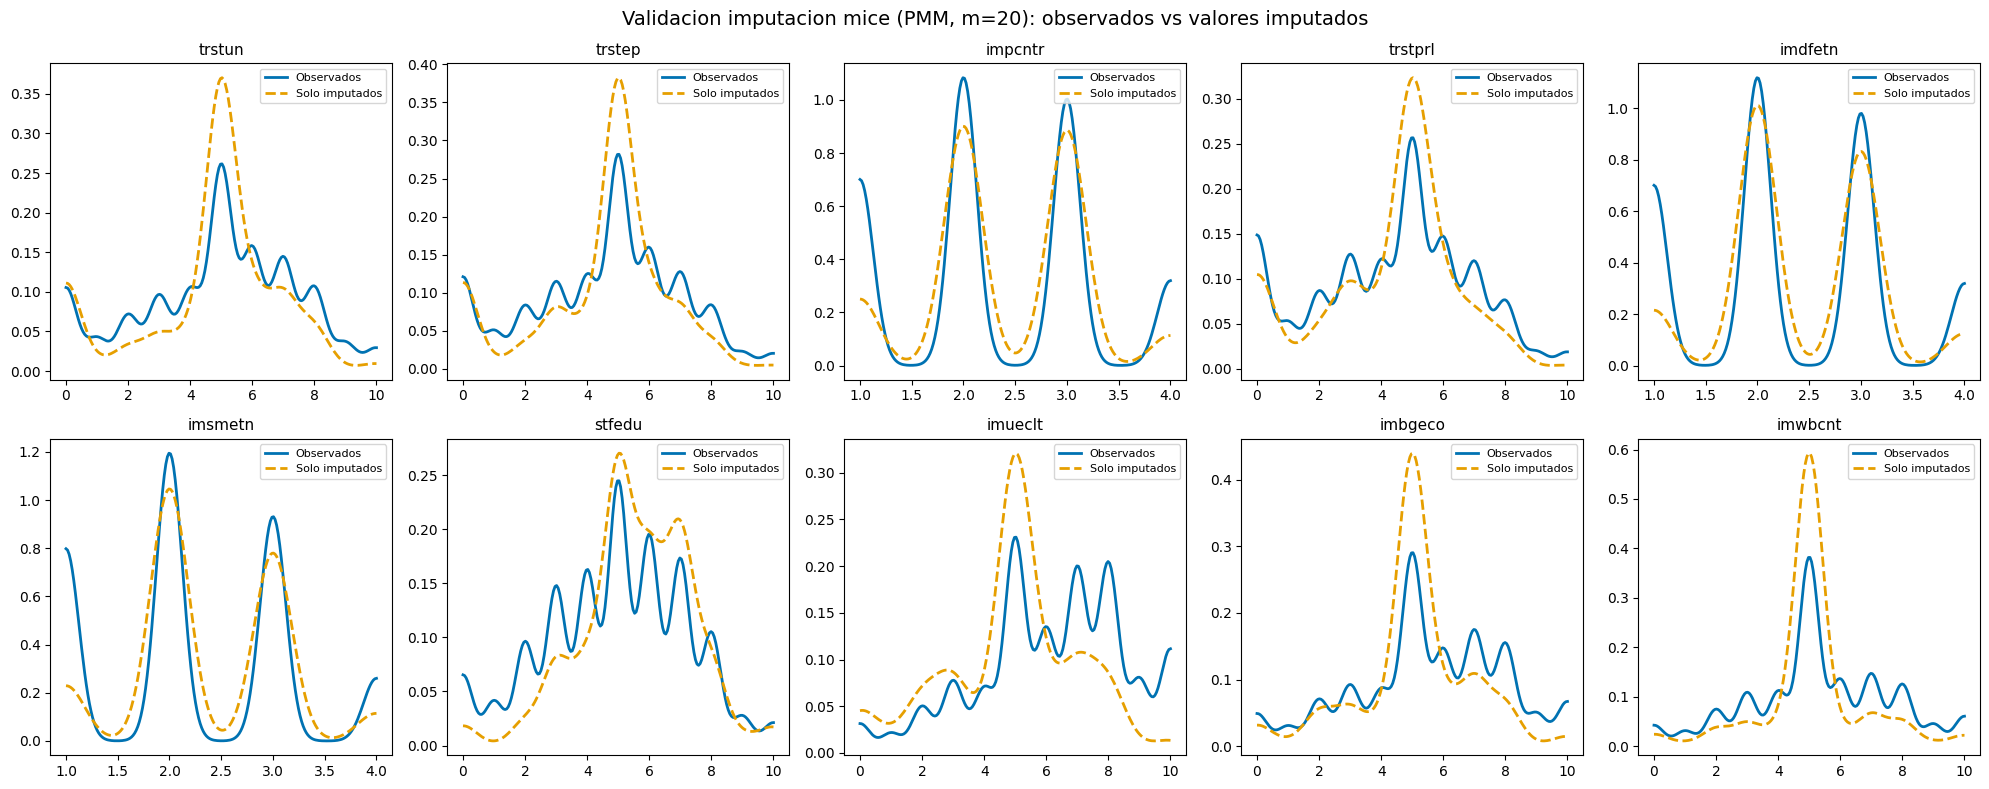

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

PATH_IMPUTED_POOLED = DIR_SPAIN / "spain_core_imputed_pooled.csv"

if not PATH_IMPUTED_POOLED.exists():
    raise FileNotFoundError(
        f"Ejecuta primero: Rscript R/ess_spain/spain_mice_imputation.R\n"
        f"Falta: {PATH_IMPUTED_POOLED}"
    )

df_obs = pd.read_csv(PATH_SPAIN_CORE_DATA)
df_imp = pd.read_csv(PATH_IMPUTED_POOLED)

vars_check = (
    missing_diagnosis_spain.loc[missing_diagnosis_spain["missing_n"] > 0, "variable"]
    .head(10)
    .tolist()
)

OKABE_BLUE = "#0072B2"
OKABE_ORANGE = "#E69F00"

n_cols = 5
n_rows = int(np.ceil(len(vars_check) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, var in enumerate(vars_check):
    ax = axes[i]
    datos_reales = df_obs[var].dropna()
    mask_missing = df_obs[var].isna()
    datos_imputados = df_imp.loc[mask_missing, var].dropna()

    if len(datos_reales) < 2:
        ax.set_title(f"{var} (pocos datos)")
        continue

    x_min = min(datos_reales.min(), datos_imputados.min() if len(datos_imputados) else datos_reales.min())
    x_max = max(datos_reales.max(), datos_imputados.max() if len(datos_imputados) else datos_reales.max())
    x = np.linspace(x_min, x_max, 200)

    kde_real = gaussian_kde(datos_reales)
    ax.plot(x, kde_real(x), color=OKABE_BLUE, linewidth=2, label="Observados")

    if len(datos_imputados) > 10:
        kde_imp = gaussian_kde(datos_imputados)
        ax.plot(
            x,
            kde_imp(x),
            color=OKABE_ORANGE,
            linewidth=2,
            linestyle="--",
            label="Solo imputados",
        )

    ax.set_title(var, fontsize=11)
    ax.legend(fontsize=8)

for j in range(len(vars_check), len(axes)):
    axes[j].axis("off")

plt.suptitle("Validacion imputacion mice (PMM, m=20): observados vs valores imputados", fontsize=14)
plt.tight_layout()
plt.show()

## Pre-EFA: Checks de adecuacion del dataset

Antes de la EFA verificamos:
1. **Estadisticos descriptivos univariados** — skewness y kurtosis por variable
2. **KMO** — adecuacion muestral global (>=0.70) y por variable (>=0.50)
3. **Test de Bartlett** — la matriz no es identidad (p<0.001)
4. **Determinante** — ausencia de multicolinealidad perfecta (>0.00001)
5. **Heatmap de correlaciones** — detectar pares r>0.85 o r<0.10

Input: `spain_core_imputed.csv` (dataset pooled con modo de las 20 imputaciones PMM)

Referencias: Watkins (2018) *Journal of Black Psychology*; Lloret et al. (2017); Kaiser (1974)

In [22]:
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

PATH_IMPUTED = DIR_SPAIN / "spain_core_imputed.csv"
df_imp = pd.read_csv(PATH_IMPUTED)

# Cargar tambien las variables core para tener etiquetas
var_labels = pd.read_csv(DIR_SPAIN / "spain_core_variables.csv")[["variable", "label"]]
label_map = dict(zip(var_labels["variable"], var_labels["label"]))

print(f"Dataset imputado: {df_imp.shape[0]} filas x {df_imp.shape[1]} variables")
print(f"Missing restante: {df_imp.isna().sum().sum()} (debe ser 0)")

Dataset imputado: 21296 filas x 45 variables
Missing restante: 0 (debe ser 0)


In [23]:
# --- 1. Estadisticos descriptivos univariados ---
rows = []
for var in df_imp.columns:
    x = df_imp[var].dropna()
    rows.append({
        "variable": var,
        "label": label_map.get(var, ""),
        "mean": round(x.mean(), 3),
        "sd": round(x.std(), 3),
        "min": x.min(),
        "max": x.max(),
        "skewness": round(stats.skew(x), 3),
        "kurtosis": round(stats.kurtosis(x), 3),  # excess kurtosis
    })

desc = pd.DataFrame(rows)

# Variables con skewness o kurtosis extremos (Curran et al. 1996: |skew|>2, |kurt|>7)
extreme = desc[(desc["skewness"].abs() > 2) | (desc["kurtosis"].abs() > 7)]

print(f"Variables con skewness o kurtosis extremos: {len(extreme)}")
print()
if len(extreme) > 0:
    print(extreme[["variable", "label", "skewness", "kurtosis"]].to_string(index=False))
    print()
print("Todos los descriptivos:")
print(desc[["variable", "mean", "sd", "skewness", "kurtosis"]].to_string(index=False))

Variables con skewness o kurtosis extremos: 12

variable                                                                       label  skewness  kurtosis
 hlthhmp Hampered in daily activities by illness/disability/infirmity/mental problem    -2.355     4.559
 dscrsex                             Discrimination of respondent's group: sexuality     9.970    97.394
 dscrrlg                              Discrimination of respondent's group: religion     8.629    72.453
 dscrrce                        Discrimination of respondent's group: colour or race    10.121   100.435
 dscroth                         Discrimination of respondent's group: other grounds     8.189    65.067
 dscrntn                           Discrimination of respondent's group: nationality     7.517    54.503
 dscrlng                              Discrimination of respondent's group: language    10.648   111.380
 dscrgrp                     Member of a group discriminated against in this country    -3.243     8.516
 dscrgn

In [24]:
from sklearn.preprocessing import StandardScaler
from numpy.linalg import det
import numpy as np

# --- 2 y 3. KMO + Bartlett ---
# Usamos factor_analyzer (pip install factor_analyzer)
try:
    from factor_analyzer import FactorAnalyzer
    from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
    
    X = df_imp.values
    
    # Bartlett
    chi2, p_bartlett = calculate_bartlett_sphericity(X)
    print(f"Test de Bartlett: chi2 = {chi2:.2f}, p = {p_bartlett:.4f}")
    if p_bartlett < 0.001:
        print("  -> APTO: la matriz no es identidad (p<0.001) OK")
    else:
        print("  -> PROBLEMA: p >= 0.001")
    print()
    
    # KMO
    kmo_per_var, kmo_total = calculate_kmo(X)
    print(f"KMO global: {kmo_total:.4f}")
    if kmo_total >= 0.90:
        print("  -> Marvelous (Kaiser 1974)")
    elif kmo_total >= 0.80:
        print("  -> Meritorious")
    elif kmo_total >= 0.70:
        print("  -> Middling — aceptable")
    elif kmo_total >= 0.60:
        print("  -> Mediocre — revisar variables")
    else:
        print("  -> PROBLEMA: KMO < 0.60 — EFA no recomendada")
    print()
    
    # KMO por variable
    kmo_df = pd.DataFrame({
        "variable": df_imp.columns,
        "kmo": kmo_per_var.round(4)
    }).sort_values("kmo")
    
    problematic = kmo_df[kmo_df["kmo"] < 0.50]
    print(f"Variables con KMO < 0.50 (candidatas a eliminar): {len(problematic)}")
    if len(problematic) > 0:
        print(problematic.to_string(index=False))
    print()
    print("KMO por variable (todas):")
    print(kmo_df.to_string(index=False))
    
except ImportError:
    print("Instala factor_analyzer: pip install factor_analyzer")
    print("En el terminal con venv activo: pip install factor_analyzer")

Test de Bartlett: chi2 = 336340.02, p = 0.0000
  -> APTO: la matriz no es identidad (p<0.001) OK

KMO global: 0.8188
  -> Meritorious

Variables con KMO < 0.50 (candidatas a eliminar): 3
variable    kmo
 dscroth 0.2823
 dscrrlg 0.4608
 dscrgnd 0.4716

KMO por variable (todas):
variable    kmo
 dscroth 0.2823
 dscrrlg 0.4608
 dscrgnd 0.4716
 dscrgrp 0.5208
 dscrntn 0.5224
 dscrdsb 0.5730
 dscrsex 0.6113
 dscrrce 0.6535
    pray 0.6604
 rlgatnd 0.6651
 gincdif 0.6827
 hlthhmp 0.7179
 clsprty 0.7207
   happy 0.7240
 dscrage 0.7241
 stflife 0.7373
 sclmeet 0.7443
  health 0.7549
 dscretn 0.7922
  sclact 0.8226
 polintr 0.8241
 imdfetn 0.8256
 pplfair 0.8258
 ppltrst 0.8322
 dscrlng 0.8420
 hincfel 0.8530
  trstun 0.8604
 stfhlth 0.8679
  trstep 0.8686
  stfedu 0.8715
  stfgov 0.8754
 impcntr 0.8762
  pplhlp 0.8815
 imsmetn 0.8853
  stfeco 0.8929
 aesfdrk 0.8930
 imwbcnt 0.8976
 trstplc 0.8986
 imueclt 0.8996
 freehms 0.9117
 trstlgl 0.9164
 imbgeco 0.9174
 trstprl 0.9309
 trstplt 0.9319
  

C:\Users\Guille\proyectos\eu-political-observatory\venv\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [25]:
# --- 4. Determinante de la matriz de correlaciones ---
corr_matrix = np.corrcoef(df_imp.values.T)
d = det(corr_matrix)

print(f"Determinante de la matriz de correlaciones: {d:.6e}")
if d > 0.00001:
    print("  -> OK: no hay multicolinealidad perfecta")
elif d > 0:
    print("  -> ADVERTENCIA: determinante muy bajo, posible multicolinealidad alta")
else:
    print("  -> PROBLEMA: determinante <= 0, matriz singular")

Determinante de la matriz de correlaciones: 1.366189e-07
  -> ADVERTENCIA: determinante muy bajo, posible multicolinealidad alta


Pares con |r| > 0.85 (posible multicolinealidad): 2
  impcntr — imdfetn: r = 0.895
  imdfetn — imsmetn: r = 0.884

Variables con correlacion maxima < 0.10 (sin relacion con ninguna otra): 0


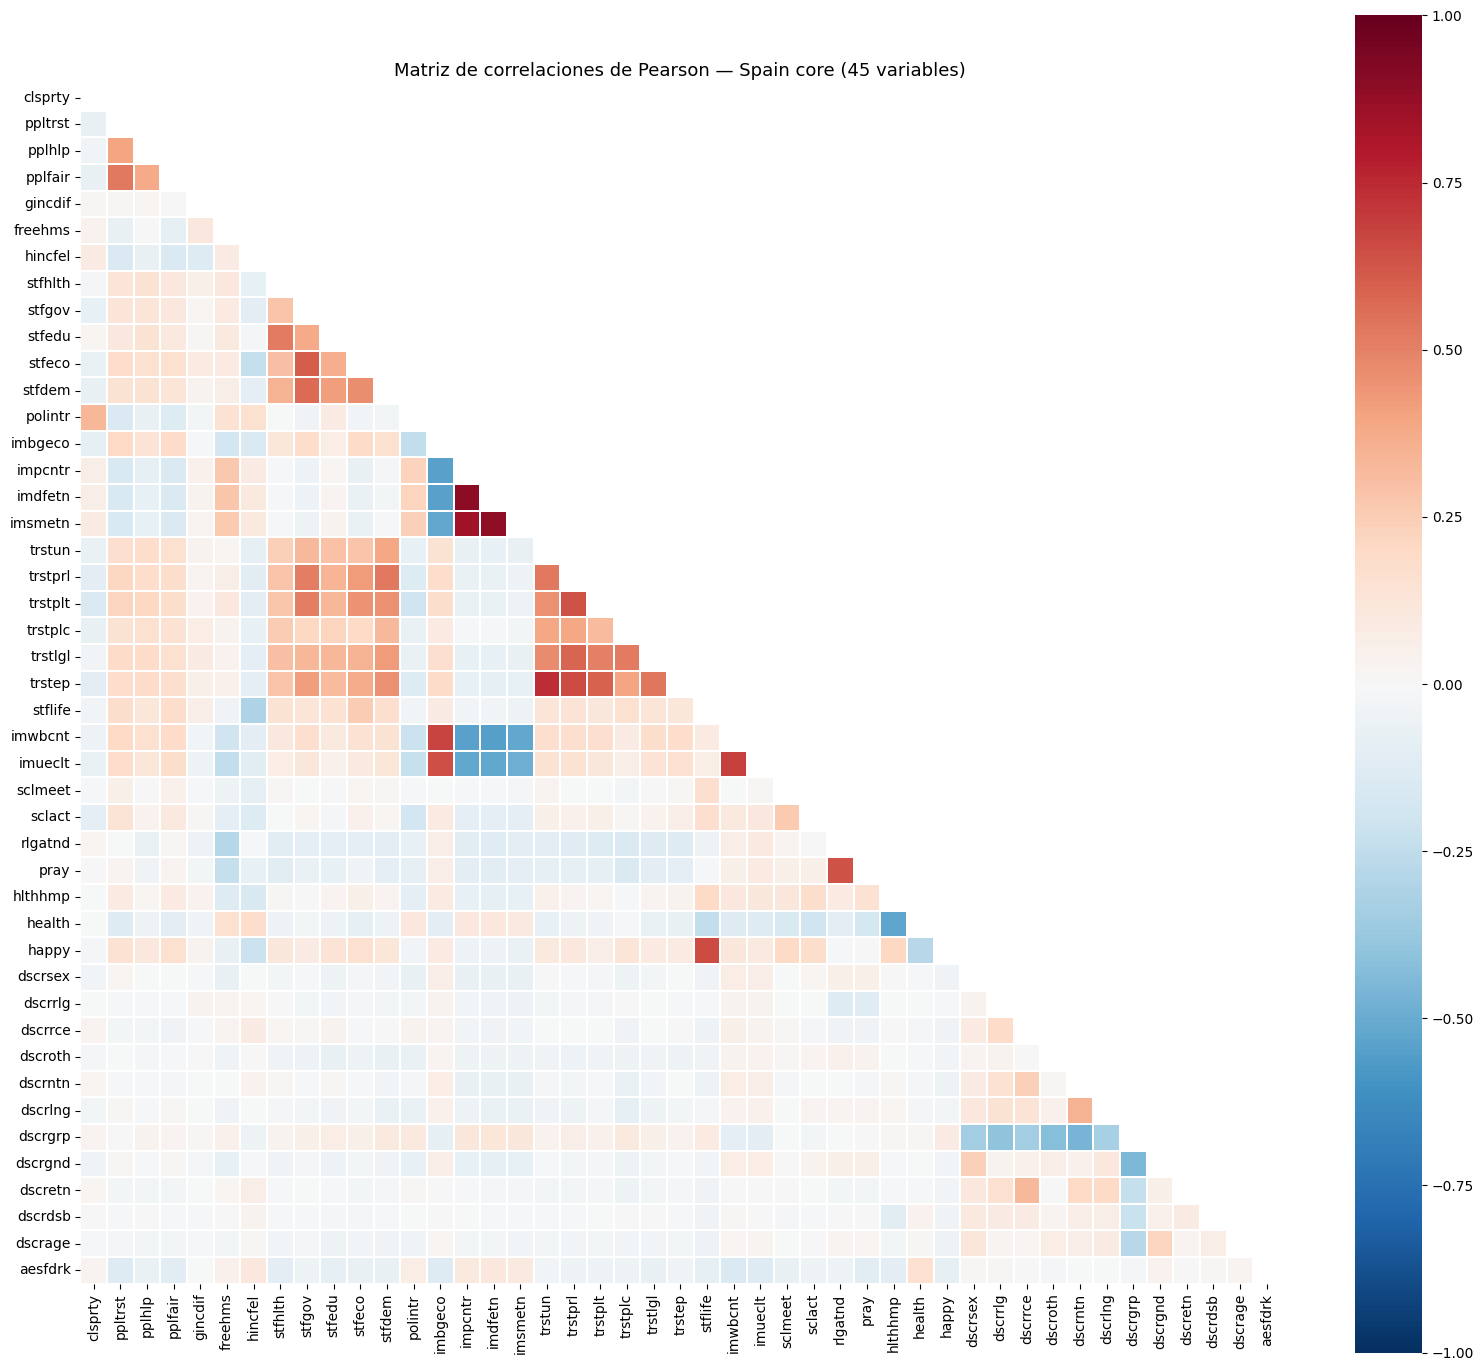

In [26]:
# --- 5. Heatmap de correlaciones + deteccion de pares problematicos ---
corr_df = df_imp.corr()

# Pares con r > 0.85 (multicolinealidad)
high_corr = []
low_corr_vars = []
vars_list = list(corr_df.columns)

for i, v1 in enumerate(vars_list):
    max_corr = corr_df[v1].drop(v1).abs().max()
    if max_corr < 0.10:
        low_corr_vars.append((v1, round(max_corr, 3)))
    for j, v2 in enumerate(vars_list):
        if j <= i:
            continue
        r = corr_df.loc[v1, v2]
        if abs(r) > 0.85:
            high_corr.append((v1, v2, round(r, 3)))

print(f"Pares con |r| > 0.85 (posible multicolinealidad): {len(high_corr)}")
for v1, v2, r in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f"  {v1} — {v2}: r = {r}")

print(f"\nVariables con correlacion maxima < 0.10 (sin relacion con ninguna otra): {len(low_corr_vars)}")
for v, r in low_corr_vars:
    print(f"  {v}: max |r| = {r}")

# Heatmap
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_df, dtype=bool))
sns.heatmap(
    corr_df,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    vmin=-1, vmax=1,
    annot=False,
    square=True,
    linewidths=0.3,
    ax=ax
)
ax.set_title("Matriz de correlaciones de Pearson — Spain core (45 variables)", fontsize=13)
plt.tight_layout()
plt.show()

In [27]:
# Eliminar variables problemáticas y recalcular checks
vars_to_drop = ["dscroth", "dscrrlg", "dscrgnd", "imdfetn"]
df_imp_clean = df_imp.drop(columns=vars_to_drop)

print(f"Variables antes: {df_imp.shape[1]} → después: {df_imp_clean.shape[1]}")
print(f"Eliminadas: {vars_to_drop}")
print()

# KMO + Bartlett
X2 = df_imp_clean.values
chi2, p_bartlett2 = calculate_bartlett_sphericity(X2)
kmo_per_var2, kmo_total2 = calculate_kmo(X2)

print(f"Bartlett: chi2={chi2:.2f}, p={p_bartlett2:.4f}")
print(f"KMO global: {kmo_total2:.4f}")
print()

# KMO por variable
kmo_df2 = pd.DataFrame({
    "variable": df_imp_clean.columns,
    "kmo": kmo_per_var2.round(4)
}).sort_values("kmo")
problematic2 = kmo_df2[kmo_df2["kmo"] < 0.50]
print(f"Variables con KMO < 0.50: {len(problematic2)}")
if len(problematic2) > 0:
    print(problematic2.to_string(index=False))
print()

# Determinante
corr_matrix2 = np.corrcoef(df_imp_clean.values.T)
d2 = np.linalg.det(corr_matrix2)
print(f"Determinante: {d2:.6e}")
if d2 > 0.00001:
    print("  -> OK")
elif d2 > 0:
    print("  -> Bajo pero positivo — advertencia")
else:
    print("  -> PROBLEMA: singular")

Variables antes: 45 → después: 41
Eliminadas: ['dscroth', 'dscrrlg', 'dscrgnd', 'imdfetn']

Bartlett: chi2=272587.25, p=0.0000
KMO global: 0.8382

Variables con KMO < 0.50: 0

Determinante: 2.735352e-06
  -> Bajo pero positivo — advertencia


C:\Users\Guille\proyectos\eu-political-observatory\venv\Lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


In [28]:
# --- Eliminacion de imsmetn: justificacion teorica ---
# imsmetn es el item menos estable cross-culturalmente en la escala de
# inmigracion del ESS (Nickel et al. 2024, MDA; ESS EduNet). Sus cargas
# factoriales varian considerablemente entre paises mientras impcntr e
# imdfetn son mas robustos. Para un proyecto comparativo entre paises,
# mantener imsmetn penaliza la invarianza de medida.
#
# Decision final de eliminacion pre-EFA:
#   dscroth  (KMO=0.28) - no encaja en ningun factor
#   dscrrlg  (KMO=0.46) - no encaja en ningun factor
#   dscrgnd  (KMO=0.47) - no encaja en ningun factor
#   imdfetn  (r>0.85 con impcntr Y imsmetn) - nexo de multicolinealidad
#   imsmetn  (invarianza cross-cultural debil, Nickel et al. 2024)

vars_to_drop_final = ["dscroth", "dscrrlg", "dscrgnd", "imdfetn", "imsmetn"]
df_efa = df_imp.drop(columns=vars_to_drop_final)

print(f"Variables antes: {df_imp.shape[1]} -> despues: {df_efa.shape[1]}")
print(f"Eliminadas: {vars_to_drop_final}")
print()

# Recalculo final
X3 = df_efa.values
chi2, p3 = calculate_bartlett_sphericity(X3)
kmo_per3, kmo3 = calculate_kmo(X3)
corr3 = np.corrcoef(df_efa.values.T)
d3 = np.linalg.det(corr3)

print(f"Bartlett: chi2={chi2:.2f}, p={p3:.4f}")
print(f"KMO global: {kmo3:.4f}")
print()

kmo_df3 = pd.DataFrame({
    "variable": df_efa.columns,
    "kmo": kmo_per3.round(4)
}).sort_values("kmo")

problematic3 = kmo_df3[kmo_df3["kmo"] < 0.50]
print(f"Variables con KMO < 0.50: {len(problematic3)}")
if len(problematic3) > 0:
    print(problematic3.to_string(index=False))
print()
print(f"Determinante: {d3:.6e}")
if d3 > 0.00001:
    print("  -> OK")
elif d3 > 0:
    print("  -> Bajo pero positivo")
else:
    print("  -> PROBLEMA: singular")

Variables antes: 45 -> despues: 40
Eliminadas: ['dscroth', 'dscrrlg', 'dscrgnd', 'imdfetn', 'imsmetn']

Bartlett: chi2=245055.74, p=0.0000
KMO global: 0.8422

Variables con KMO < 0.50: 0

Determinante: 9.976021e-06
  -> Bajo pero positivo


In [29]:
# Pares con r > 0.85 en el dataset final de 40 variables
corr_df3 = df_efa.corr()
high_corr3 = []

vars3 = list(corr_df3.columns)
for i, v1 in enumerate(vars3):
    for j, v2 in enumerate(vars3):
        if j <= i:
            continue
        r = corr_df3.loc[v1, v2]
        if abs(r) > 0.80:
            high_corr3.append((v1, v2, round(r, 3)))

high_corr3.sort(key=lambda x: -abs(x[2]))
print(f"Pares con |r| > 0.80:")
for v1, v2, r in high_corr3:
    print(f"  {v1} — {v2}: r = {r}")

Pares con |r| > 0.80:
